# Estructurar panel para STATA
## Objetivo
- Explorar el panel de datos
- Elegir las variables de resultado, tratamiento, control e instrumento
- Estructurar los datos para hacer la estimación en STATA
## Asistencia
- [Conversación con Chat GPT](https://chatgpt.com/g/g-p-68d150c943888191a382d4a582b0baff-tesis-peg/c/69e80cd2-8a7c-83e9-b5fc-caabec8f45df)


# Herramientas

## Paquetes

In [1]:
# Manejar datos
import pandas as pd
pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x)) # Configuración para mostrar separador de miles

# Manejar datos espaciales
import geopandas as gpd
from shapely.validation import make_valid

# Calculo numérico
import numpy as np

# Utilidades
from tqdm import tqdm # revisar avance de ciclos
import warnings # Manejar warnings
import unicodedata # Manejar caracteres especiales de los strings

# Gráficas
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import seaborn as sns

# Estimar modelos econométricos
#pip install conda-forge::linearmodels
from linearmodels.panel import PanelOLS
from linearmodels.iv import IV2SLS


# Cargar datos

## Panel de datos

In [3]:
# Cargar datos
PANEL_crudo = pd.read_parquet('../7_ArmarPanel/outputs/PANEL_2026_06_09.parquet')

# Mostrar resumen de los datos disponibles
print(f"\n{'*'*50}\nResumen del PANEL crudo\n{'*'*50}")
PANEL_crudo.groupby('tipo_variable').agg({'variable':'nunique',
                                    'Año':['min', 'max'],
                                    'Código Dane municipio':'nunique',
                                    'valor':'count'})


**************************************************
Resumen del PANEL crudo
**************************************************


variable   Año        \
                                       nunique   min   max   
tipo_variable                                                
Control - Insumos agrícolas                770  2021  2026   
Control - Otros cultivos                    48  2019  2024   
Control - insumos agropecuarios            103  2021  2026   
Instrumento - Distancia al oro               4  2026  2026   
Instrumento - Mineros subsistencia           8  2026  2026   
Instrumento - area titulo minero             2  1989  2021   
Instrumento - potencial geológico oro        1  2026  2026   
Minería Ilegal                               5  2004  2014   
Resultado                                   12  2019  2024   
Tratamiento - producción regalías           76  2012  2026   

                                      Código Dane municipio   valor  
                                                    nunique   count  
tipo_variable                                                        
Control - Insumos agrícolas                             190   53324  
Control - Otros cultivos                               1102  212868  
Control - insumos agropecuarios                         186    4876  
Instrumento - Distancia al oro                         1122    4488  
Instrumento - Mineros subsistencia                     1123     799  
Instrumento - area titulo minero                        124   16368  
Instrumento - potencial geológico oro                  1122    1122  
Minería Ilegal                                          940   39302  
Resultado                                               744   25674  
Tratamiento - producción regalías                       881   22638

# Seleccionar variables

## Variable de Resultado

In [5]:
# Explorar disponibilidad de datos para usar como variable de resultado:
display(PANEL_crudo[PANEL_crudo['tipo_variable']=='Resultado']
        .groupby(['variable', 'Año'])['Código Dane municipio']
        .nunique()
        .unstack())

# Elijo usar "Café_Producción (t)" para la propuesta por las siguientes razones
# - Tengo observaciones de >600 municipios, mientras que con agucate tengo <200
# Elijo producción por encima del área porque las diferencias en producción
# deben ser más sensibles a los factores de producción <mano de obra>, <agua> y similares
# que el área sembrada
variable_resultado = 'Café_Producción (t)'

Año,2019,2020,2021,2022,2023,2024
variable,,,,,,
Aguacate Hass_Producción (t),NaN,218.00,232.00,238.00,245.00,258.00
Aguacate Hass_Área cosechada (ha),NaN,218.00,232.00,238.00,245.00,258.00
Aguacate Hass_Área sembrada (ha),NaN,218.00,232.00,238.00,245.00,258.00
Aguacate Papelillo_Producción (t),NaN,107.00,105.00,103.00,104.00,108.00
Aguacate Papelillo_Área cosechada (ha),NaN,107.00,105.00,103.00,104.00,108.00
Aguacate Papelillo_Área sembrada (ha),NaN,107.00,105.00,103.00,104.00,108.00
Aguacate demás variedades_Producción (t),569.00,499.00,491.00,487.00,492.00,495.00
Aguacate demás variedades_Área cosechada (ha),569.00,499.00,491.00,487.00,492.00,495.00
Aguacate demás variedades_Área sembrada (ha),569.00,499.00,491.00,487.00,492.00,495.00


## Control - area de los demás cultivos

In [6]:
# El control natural para la variable seleccioanda es la producción de los cultivos diferentes:
otros_cultivos = PANEL_crudo[PANEL_crudo['tipo_variable']=='Control - Otros cultivos']['variable'].unique()
otros_cultivos = otros_cultivos[pd.Series(otros_cultivos).str.contains('No_Café')]
area_cosechada_otros_cultivos = otros_cultivos[pd.Series(otros_cultivos).str.contains('Área cosechada')]
print(area_cosechada_otros_cultivos)

# Calcular el area cosechada de todo los demás cultivos
# en cada municipio en cada año
filas = PANEL_crudo['variable'].isin(area_cosechada_otros_cultivos)
panel_area_cosechada_otros_cultivos = PANEL_crudo[filas].groupby(['Código Dane municipio', 'Año'])['valor'].sum().reset_index()
panel_area_cosechada_otros_cultivos['auxiliar'] = 'Área cosechada de todos los demás cultivos'
panel_area_cosechada_otros_cultivos['tipo_variable'] = 'Control - Otros cultivos'
variable_control_area_cosechada_otros_cultivos = 'area_cosechada_HA_no_Café'
panel_area_cosechada_otros_cultivos['variable'] = variable_control_area_cosechada_otros_cultivos

# Incluir la variable en el PANEL
PANEL_crudo = pd.concat([PANEL_crudo, panel_area_cosechada_otros_cultivos])

['No_Café_Cultivos tropicales tradicionales_Área cosechada (ha)'
 'No_Café_Frutales_Área cosechada (ha)'
 'No_Café_Hortalizas_Área cosechada (ha)'
 'No_Café_Leguminosas_Área cosechada (ha)'
 'No_Café_Raíces y tubérculos_Área cosechada (ha)'
 'No_Café_Cultivos para condimentos, bebidas medicinales y aromáticas_Área cosechada (ha)'
 'No_Café_Cereales_Área cosechada (ha)'
 'No_Café_Oleaginosas_Área cosechada (ha)']


## Instrumentos
Los poligonos que he procesado hasta el momento han sido solo de oro. En las bases de datos están disponibles polígonos de otras minerías. Por el momento, solo he procesado las de oro
- Potencial SGC
- Título minero

### Indicador de potencial geológico

In [7]:
# Mostrar datos disponibles de posibles instrumentos
display(PANEL_crudo[PANEL_crudo['tipo_variable'].str.contains('Instrumento')]
        ['variable'].unique())

# Como solo he procesado los polígonos de <titulos mineros> y <potencial geológico>
# del oro, voy a tomar estas variables como tratamientos
# El area titulada es de oro. Me falta aclararlo en los nombres de las variables
#variable_instrumentos = ['area_titulada_stock_m2', 'pct_municipio_potencial_oro', 'LOG_subsistencia_METALES_PRECIOSOS_x10khab']
variable_instrumental_1 = 'proximidad_geo_oro'
variable_instrumental_2 = 'pct_municipio_potencial_oro'

array(['area_solicitada_stock_m2', 'area_titulada_stock_m2',
       'pct_municipio_potencial_oro', 'LOG_subsistencia_ARCILLA_x10khab',
       'LOG_subsistencia_ARENAS_DE_RIO_x10khab',
       'LOG_subsistencia_ESMERALDAS_x10khab',
       'LOG_subsistencia_GRAVAS_DE_RIO_x10khab',
       'LOG_subsistencia_METALES_PRECIOSOS_x10khab',
       'LOG_subsistencia_MORRALLA_x10khab',
       'LOG_subsistencia_PIEDRAS_PRECIOSAS_x10khab',
       'LOG_subsistencia_PIEDRAS_SEMIPRECIOSAS_x10khab',
       'dist_potencial_km', 'dist_aluvial_km', 'dist_geo_oro_km',
       'proximidad_geo_oro'], dtype=object)

## Variable de tratamiento

In [8]:
# Como las variables instrumentales están definidas con el oro,
# por ahora solo puedo tomar la variable de tratamiento como la producción
# de oro asociada a relgalías.
display(PANEL_crudo[PANEL_crudo['tipo_variable']=='Tratamiento - producción regalías']
       ['variable'].unique())

# Elijo producción de oro como variable de tratamiento
variable_tratamiento = 'Produccion_ORO_GRAMOS'

array(['Produccion_ARCILLAS_TONELADAS',
       'Produccion_ARCILLAS BENTONITICA_TONELADAS',
       'Produccion_ARCILLAS CAOLINITICA_TONELADAS',
       'Produccion_ARCILLAS CERAMICAS_TONELADAS',
       'Produccion_ARCILLAS FERRUGINOSAS_TONELADAS',
       'Produccion_ARCILLAS MISCELANEAS_TONELADAS',
       'Produccion_ARENA DE CANTERA_METROS CUBICOS',
       'Produccion_ARENA DE RIO_METROS CUBICOS',
       'Produccion_ARENAS_METROS CUBICOS',
       'Produccion_ARENAS NEGRAS_KILOGRAMOS',
       'Produccion_ARENAS SILICEAS_METROS CUBICOS',
       'Produccion_ASFALTITA_METROS CUBICOS',
       'Produccion_AZUFRE_TONELADAS', 'Produccion_BARITA_TONELADAS',
       'Produccion_BASALTO_TONELADAS', 'Produccion_BAUXITA_TONELADAS',
       'Produccion_CALIZAS_TONELADAS', 'Produccion_CARBON_TONELADAS',
       'Produccion_CARBON METALURGICO_TONELADAS',
       'Produccion_CARBON TERMICO_TONELADAS',
       'Produccion_CARBONATO DE CALCIO_TONELADAS',
       'Produccion_COBRE_KILOGRAMOS',
       'Produccio

In [9]:
# En los registros de producción asociada a regalías, hay producción que
# está sin asignar a algún municipio. Aparece con 'Código Dane municipio'=-2
# Explorar si la producción de oro sin clasificar es sustancial frente a lo clasificado
filas = PANEL_crudo['variable']==variable_tratamiento
explorar_tratamiento = PANEL_crudo[filas]

# Identificar la producción clasificada de la no clasificada
explorar_tratamiento['Producción_clasificada'] = True
filas = explorar_tratamiento['Código Dane municipio']=='-2'
explorar_tratamiento.loc[filas, 'Producción_clasificada'] = False

# Sumar y comparar
resumen = explorar_tratamiento.groupby(['Producción_clasificada', 'Año'])['valor'].sum().unstack().transpose().reset_index()
resumen['no_clasificado / clasificado (%)'] = resumen[False]/resumen[True]*100
display(resumen)

C:\Users\jcalf\AppData\Local\Temp\ipykernel_15412\614032009.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  explorar_tratamiento['Producción_clasificada'] = True


Producción_clasificada,Año,False,True,no_clasificado / clasificado (%)
0,2012,NaN,"66,222,599.99",NaN
1,2013,NaN,"55,987,289.31",NaN
2,2014,NaN,"57,900,560.72",NaN
3,2015,NaN,"59,664,677.34",NaN
4,2016,NaN,"63,182,644.16",NaN
5,2017,NaN,"43,242,981.96",NaN
6,2018,NaN,"35,987,221.01",NaN
7,2019,NaN,"38,263,553.97",NaN
8,2020,NaN,"49,488,224.81",NaN
9,2021,NaN,"58,100,266.97",NaN


In [10]:
# La producción no clasficada solo aparece en los últimos 3 años y es menos del 1%
# Como no es sustancial, elmino los datos
filas = PANEL_crudo['Código Dane municipio']=='-2'
PANEL_crudo = PANEL_crudo[~filas]

## Resumen

In [11]:
# Resumen de las variables elegidas
variables_modelo = {
    'Resultado': variable_resultado,
    'Tratamiento': variable_tratamiento,
    'Instrumemto': [variable_instrumental_1, variable_instrumental_2],
    'Controles': [variable_control_area_cosechada_otros_cultivos]
}
display(variables_modelo)

{'Resultado': 'Café_Producción (t)',
 'Tratamiento': 'Produccion_ORO_GRAMOS',
 'Instrumemto': ['proximidad_geo_oro', 'pct_municipio_potencial_oro'],
 'Controles': ['area_cosechada_HA_no_Café']}

# Pre-procesamiento

## Extraer variables de interés

In [12]:
# Extraer solo las observaciones de las variables de interes
variables_de_interes = [variable_resultado,
                        variable_tratamiento,
                        variable_instrumental_1, variable_instrumental_2,
                        variable_control_area_cosechada_otros_cultivos]
panel_IV = PANEL_crudo[PANEL_crudo['variable'].isin(variables_de_interes)]

In [13]:
panel_IV['variable'].unique()

array(['Café_Producción (t)', 'Produccion_ORO_GRAMOS',
       'pct_municipio_potencial_oro', 'proximidad_geo_oro',
       'area_cosechada_HA_no_Café'], dtype=object)

In [14]:

# Asegurarse que sean valores numéricos
display(panel_IV.info())
# PENDIENTE de revisión aguas arriba y de garantizar desde 
# cuando armo el panel que estoy interpretando los valores numéricos en las magnitudes correctas
panel_IV['valor'] = pd.to_numeric(panel_IV['valor'])

display(panel_IV.info())

<class 'pandas.core.frame.DataFrame'>
Index: 14730 entries, 128766 to 6586
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Código Dane municipio  14730 non-null  object 
 1   Año                    14730 non-null  int64  
 2   variable               14730 non-null  object 
 3   valor                  14730 non-null  float64
 4   auxiliar               14730 non-null  object 
 5   tipo_variable          14730 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 805.5+ KB


None

<class 'pandas.core.frame.DataFrame'>
Index: 14730 entries, 128766 to 6586
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Código Dane municipio  14730 non-null  object 
 1   Año                    14730 non-null  int64  
 2   variable               14730 non-null  object 
 3   valor                  14730 non-null  float64
 4   auxiliar               14730 non-null  object 
 5   tipo_variable          14730 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 805.5+ KB


C:\Users\jcalf\AppData\Local\Temp\ipykernel_15412\3472366850.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  panel_IV['valor'] = pd.to_numeric(panel_IV['valor'])


None

## Construir V.I. de interacción 
Construyo una variable de itneracción entre `potencial geológico` y `precio_oro`

In [15]:
# Cargar datos
precios_commodities = pd.read_excel('../../Data/11_Precios_PinkSheet/CMO-Historical-Data-Monthly.xlsx',
                                    sheet_name='Monthly Prices',
                                   skiprows=4)

# Limpiar DF
precios_commodities = precios_commodities.drop(axis=1, index=0) # La primera fila contiene las unidades del precio
precios_commodities = precios_commodities.rename(columns={'Unnamed: 0':'fecha_string'})
precios_commodities['Año'] = precios_commodities['fecha_string'].str.split('M').str[0] # Calcular año
precios_commodities['Año'] = precios_commodities['Año'].astype(int)

# Extraer precios anuales del oro
precios_oro = precios_commodities[['Gold', 'Año']].groupby('Año')['Gold'].mean().reset_index()

# Conservar datos solo desde 2019
precios_oro = precios_oro[precios_oro['Año'] >= 2019]

# Organizar variable de precios oro
precios_oro = precios_oro.rename(columns={'Gold': 'precio_oro'})

In [16]:
print(f"Variable Instrumental 1: {variable_instrumental_1}")
print(f"Variable Instrumental 2: {variable_instrumental_2}")

Variable Instrumental 1: proximidad_geo_oro
Variable Instrumental 2: pct_municipio_potencial_oro


In [17]:
# Calcular cada instrumento
for v in [variable_instrumental_1, variable_instrumental_2]:
    # Extraer variable de potencial
    # El dato de Año=2026 en el potencial geológico del oro es artificial.
    # El potencial existía millones de años antes de que existiera cualquier civilización
    potencial_geologico = panel_IV[panel_IV['variable'] == v][['Código Dane municipio', 'valor']].rename(
        columns={'valor': 'potencial_oro'})


    # cartesian merge
    potencial_geologico['key'] = 1
    precios_oro['key'] = 1
    Z_base = potencial_geologico.merge(precios_oro, on='key').drop('key', axis=1)

    # Construir instrumento
    Z_base[f"Z_{v}_precio"] = (
        Z_base['potencial_oro'] * np.log(pd.to_numeric(Z_base['precio_oro']))
    )


    # Agregar el instrumento al panel -----------------

    # Agregar información antes de agregar al panel_IV
    Z_base['tipo_variable'] = f"Instrumento {v} geológico X Precio"
    Z_base['auxiliar'] = 'Instrumento'
    Z_base = Z_base.rename(columns={f"Z_{v}_precio":'valor'})
    Z_base['variable'] = f"Z_{v}_precio"

    # Agregar filas al panel
    columnas = ['Código Dane municipio', 'Año', 'variable', 'valor', 'auxiliar', 'tipo_variable']
    panel_IV = pd.concat([panel_IV, Z_base[columnas]])

    # Eliminar las observaciones de potencial sin interacción con precio
    #filas = panel_IV['variable']==v
    #panel_IV = panel_IV[~filas]

In [18]:
panel_IV['variable'].unique()

array(['Café_Producción (t)', 'Produccion_ORO_GRAMOS',
       'pct_municipio_potencial_oro', 'proximidad_geo_oro',
       'area_cosechada_HA_no_Café', 'Z_proximidad_geo_oro_precio',
       'Z_pct_municipio_potencial_oro_precio'], dtype=object)

In [19]:
# Extraer variable de potencial
# El dato de Año=2026 en el potencial geológico del oro es artificial.
# El potencial existía millones de años antes de que existiera cualquier civilización
potencial_geologico = panel_IV[panel_IV['variable'].isin([variable_instrumental_1, variable_instrumental_2])][['Código Dane municipio', 'valor', 'variable']].rename(
    columns={'valor': 'potencial_oro'})

# Cambira a formato wide para calcular el nuevo instrumento
potencial_geologico = potencial_geologico.pivot_table(values='potencial_oro',
                               index='Código Dane municipio',
                               columns='variable').reset_index()

# Unir area y longitud en un solo instrumento normalizado
potencial_geologico['potencial_oro'] = potencial_geologico['pct_municipio_potencial_oro']/100 + potencial_geologico['proximidad_geo_oro']
print(f"En la suma normalizada del potencial por area o por distancia, el máximo debe ser 2")
display(potencial_geologico['potencial_oro'].describe())

# cartesian merge
potencial_geologico['key'] = 1
precios_oro['key'] = 1
Z_base = potencial_geologico.merge(precios_oro, on='key').drop('key', axis=1)

# Construir instrumento
Z_base['Z_potencial_area_proximidad_precio'] = (
    Z_base['potencial_oro'] * np.log(pd.to_numeric(Z_base['precio_oro']))
)


# Agregar el instrumento al panel -----------------

# Agregar información antes de agregar al panel_IV
Z_base['tipo_variable'] = 'Instrumento potencial geológico X Precio'
Z_base['auxiliar'] = 'Instrumento'
Z_base = Z_base.rename(columns={'Z_potencial_area_proximidad_precio':'valor'})
Z_base['variable'] = 'Z_potencial_area_proximidad_precio'

# Agregar filas al panel
columnas = ['Código Dane municipio', 'Año', 'variable', 'valor', 'auxiliar', 'tipo_variable']
panel_IV = pd.concat([panel_IV, Z_base[columnas]])

# Eliminar las observaciones de potencial sin interacción con precio
# filas = panel_IV['variable']==variable_instrumental
# panel_IV = panel_IV[~filas]

En la suma normalizada del potencial por area o por distancia, el máximo debe ser 2


count   1,122.00
mean        0.65
std         0.70
min         0.00
25%         0.03
50%         0.17
75%         1.23
max         2.00
Name: potencial_oro, dtype: float64

<Axes: xlabel='Año', ylabel='precio_oro'>

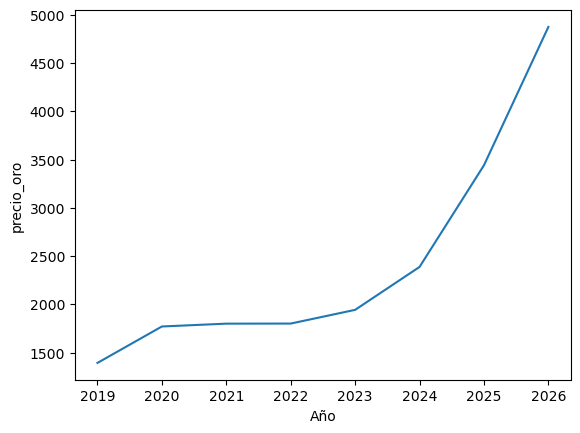

In [20]:
# Revisar datos de precio del oro
sns.lineplot(data=precios_oro,
            x='Año',
            y='precio_oro')

<Axes: xlabel='potencial_oro', ylabel='valor'>

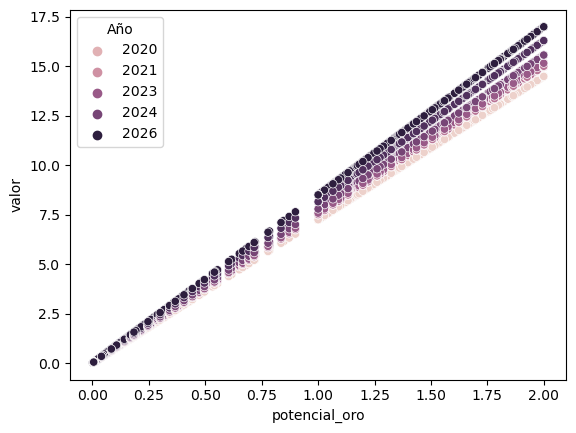

In [21]:
# Explorar valores del instrumento
sns.scatterplot(data=Z_base,
               x='potencial_oro',
               y="valor",
               hue='Año')

## Explorar disponibilidad de datos

In [22]:
# Mostrar disponibilidad inicial de datos
print(f"{'*'*20} Disponibilidad incial de datos")
display(panel_IV.groupby(['variable','Año'])['valor'].count().unstack())

# Conservar solo datos desde 2019 hasta 2024
print(f"{'*'*20} Datos desde 2019")
panel_IV = panel_IV[panel_IV['Año']>=2019]
panel_IV = panel_IV[panel_IV['Año']<=2024]
display(panel_IV.groupby(['variable','Año'])['valor'].count().unstack())


******************** Disponibilidad incial de datos


Año,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
variable,,,,,,,,,,,,,,,
Café_Producción (t),NaN,NaN,NaN,NaN,NaN,NaN,NaN,624.00,629.00,632.00,637.00,638.00,647.00,NaN,NaN
Produccion_ORO_GRAMOS,181.00,175.00,153.00,168.00,156.00,139.00,106.00,128.00,131.00,148.00,138.00,141.00,127.00,113.00,88.00
Z_pct_municipio_potencial_oro_precio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,122.00","1,122.00","1,122.00","1,122.00","1,122.00","1,122.00","1,122.00","1,122.00"
Z_potencial_area_proximidad_precio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,122.00","1,122.00","1,122.00","1,122.00","1,122.00","1,122.00","1,122.00","1,122.00"
Z_proximidad_geo_oro_precio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,122.00","1,122.00","1,122.00","1,122.00","1,122.00","1,122.00","1,122.00","1,122.00"
area_cosechada_HA_no_Café,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,097.00","1,097.00","1,097.00","1,098.00","1,098.00","1,100.00",NaN,NaN
pct_municipio_potencial_oro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,122.00"
proximidad_geo_oro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,122.00"


******************** Datos desde 2019


Año,2019,2020,2021,2022,2023,2024
variable,,,,,,
Café_Producción (t),624,629,632,637,638,647
Produccion_ORO_GRAMOS,128,131,148,138,141,127
Z_pct_municipio_potencial_oro_precio,1122,1122,1122,1122,1122,1122
Z_potencial_area_proximidad_precio,1122,1122,1122,1122,1122,1122
Z_proximidad_geo_oro_precio,1122,1122,1122,1122,1122,1122
area_cosechada_HA_no_Café,1097,1097,1097,1098,1098,1100


## Estructurar en formato Long para STATA

In [32]:
# Revisar que los valores esten alamcenados como números
display(panel_IV.info())
panel_IV['valor'] = pd.to_numeric(panel_IV['valor'])
display(panel_IV.info())

<class 'pandas.core.frame.DataFrame'>
Index: 31403 entries, 128766 to 8973
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Código Dane municipio  31403 non-null  object 
 1   Año                    31403 non-null  int64  
 2   variable               31403 non-null  object 
 3   valor                  31403 non-null  float64
 4   auxiliar               31403 non-null  object 
 5   tipo_variable          31403 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.7+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 31403 entries, 128766 to 8973
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Código Dane municipio  31403 non-null  object 
 1   Año                    31403 non-null  int64  
 2   variable               31403 non-null  object 
 3   valor                  31403 non-null  float64
 4   auxiliar               31403 non-null  object 
 5   tipo_variable          31403 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.7+ MB


None

In [33]:
# Crear panel LONG
long_panel_IV = panel_IV.pivot_table(
    index=['Código Dane municipio', 'Año'],
    columns='variable',
    values='valor').reset_index()

In [34]:
long_panel_IV

variable,Código Dane municipio,Año,Café_Producción (t),Produccion_ORO_GRAMOS,Z_pct_municipio_potencial_oro_precio,Z_potencial_area_proximidad_precio,Z_proximidad_geo_oro_precio,area_cosechada_HA_no_Café
0,05001,2019,517.00,NaN,0.00,5.22,5.22,"1,131.50"
1,05001,2020,452.00,NaN,0.00,5.39,5.39,"1,015.20"
2,05001,2021,276.10,NaN,0.00,5.40,5.40,890.22
3,05001,2022,241.18,NaN,0.00,5.40,5.40,"1,242.10"
4,05001,2023,238.66,"2,717.11",0.00,5.45,5.45,838.08
...,...,...,...,...,...,...,...,...
6727,99773,2020,NaN,NaN,0.00,6.25,6.25,"3,194.50"
6728,99773,2021,NaN,NaN,0.00,6.26,6.26,"3,165.00"
6729,99773,2022,NaN,NaN,0.00,6.26,6.26,"3,275.00"
6730,99773,2023,NaN,NaN,0.00,6.33,6.33,"3,497.00"


## Calcular variables en logaritmos

In [36]:
long_panel_IV['LOG_Café_Producción (t)'] = np.log1p(long_panel_IV['Café_Producción (t)'])
long_panel_IV['LOG_Produccion_ORO_GRAMOS'] = np.log1p(long_panel_IV['Produccion_ORO_GRAMOS'])
long_panel_IV['LOG_area_cosechada_HA_no_Café'] = np.log1p(long_panel_IV['area_cosechada_HA_no_Café'])

## Explorar datos del panel

<Axes: xlabel='Z_potencial_area_proximidad_precio', ylabel='LOG_Produccion_ORO_GRAMOS'>

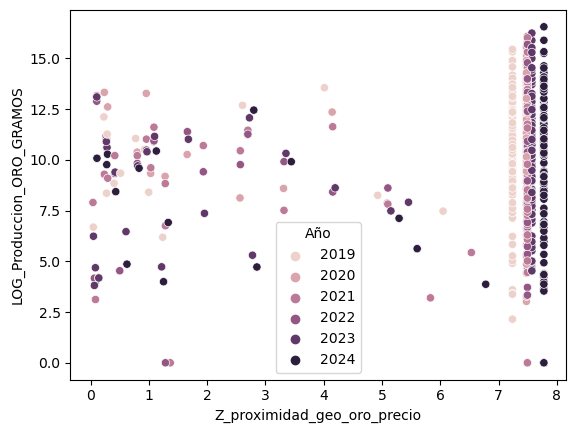

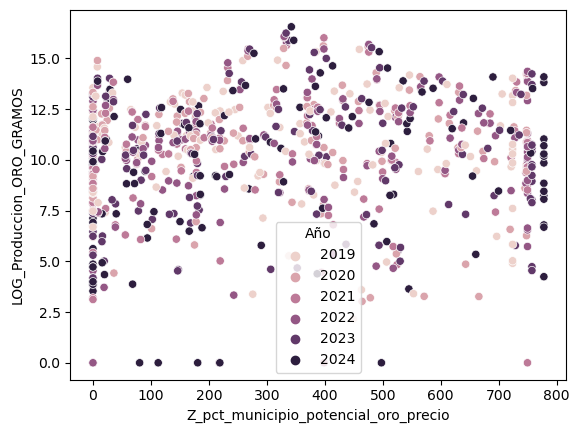

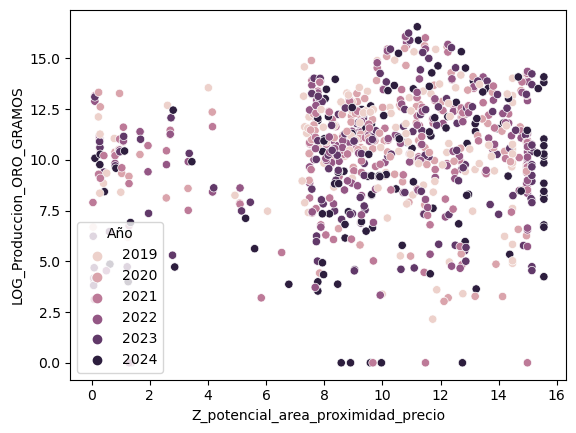

In [37]:
sns.scatterplot(data=long_panel_IV,
                y='LOG_Produccion_ORO_GRAMOS',
                x=f"Z_{variable_instrumental_1}_precio",
               hue='Año')

plt.subplots()
sns.scatterplot(data=long_panel_IV,
                y='LOG_Produccion_ORO_GRAMOS',
                x=f"Z_{variable_instrumental_2}_precio",
               hue='Año')

plt.subplots()
sns.scatterplot(data=long_panel_IV,
                y='LOG_Produccion_ORO_GRAMOS',
                x='Z_potencial_area_proximidad_precio',
               hue='Año')


count       127.00
mean     72,453.57
std     142,792.91
min          21.57
25%       2,643.56
50%      17,307.30
75%      61,993.32
max     763,753.06
Name: Produccion_ORO_GRAMOS, dtype: float64

C:\Users\jcalf\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


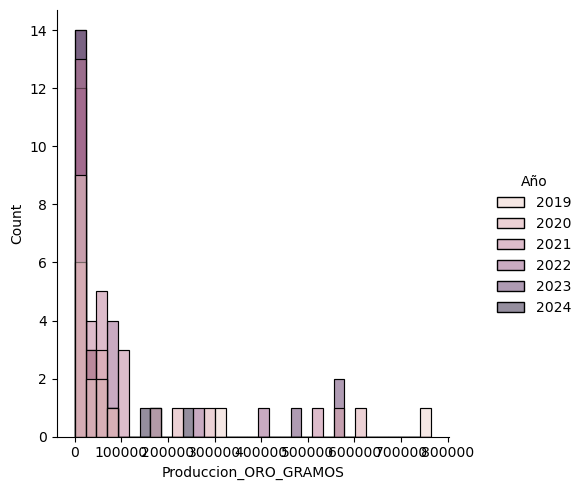

In [38]:
# Revisar los municipios sin potencial de oro, pero con producción de oro
revisar = long_panel_IV[(long_panel_IV[F"Z_{variable_instrumental_2}_precio"]==0) &
                        (long_panel_IV['Produccion_ORO_GRAMOS']>0)] 
display(revisar['Produccion_ORO_GRAMOS'].describe())

sns.displot(data=revisar, x='Produccion_ORO_GRAMOS', hue='Año')

In [39]:
# Extraer potencial geológico
potencial_geologico = PANEL_crudo[PANEL_crudo['variable']==variable_instrumental_2]

# Identificar municipios con producción de oro y sin potencial geológico
municipios_revisar = revisar['Código Dane municipio'].unique()

<Axes: >

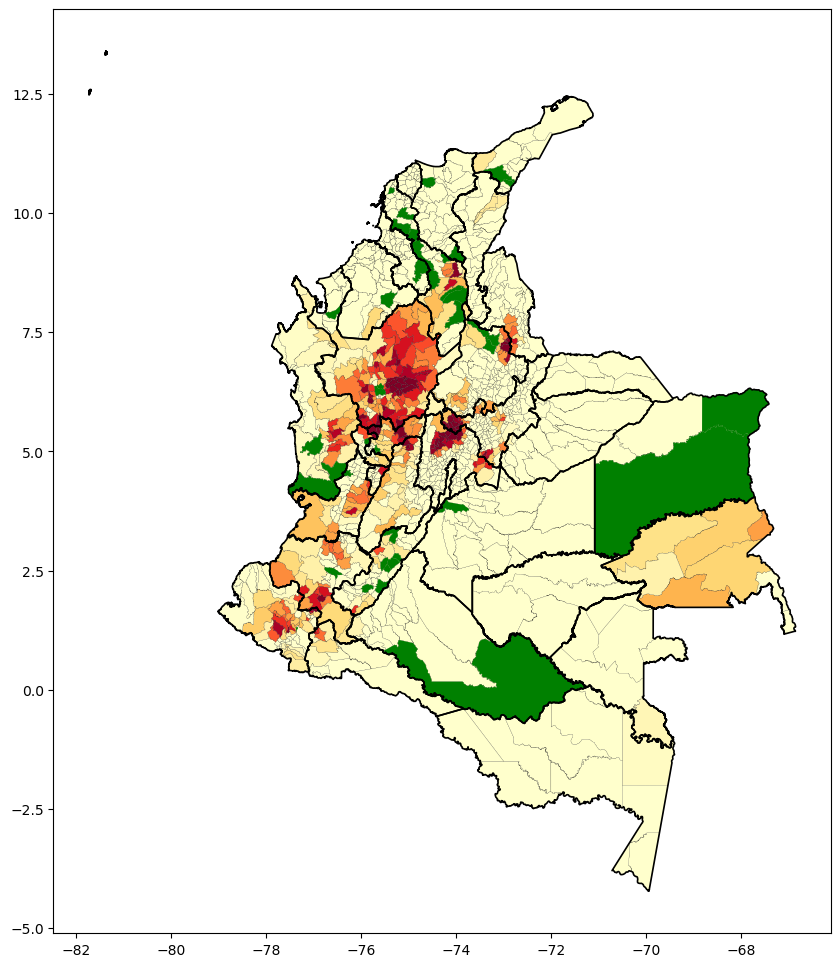

In [40]:
mapa_municipios = gdf_municipios.rename(columns={'mpio_cdpmp':'Código Dane municipio'}).merge(
    potencial_geologico[['Código Dane municipio', 'valor']],
    on='Código Dane municipio',
    how='left')


mapa_municipios_revisar = gdf_municipios.rename(columns={'mpio_cdpmp':'Código Dane municipio'})
mapa_municipios_revisar = mapa_municipios_revisar[mapa_municipios_revisar['Código Dane municipio'].isin(municipios_revisar)]

# Elementos básicos de la gráfica
fig, ax = plt.subplots(figsize=(12, 12))

# Contornos de departamentos ----------------------------------------------
gdf_departamentos.boundary.plot(ax=ax, linewidth=1.2, color='black')

# Colorear los municipios según el porcentaje de area cubierto -------------
mapa_municipios.plot(
    column="valor",
    cmap="YlOrRd",
    ax=ax,
    legend=False,
    linewidth=0.1,
    edgecolor="black",
    missing_kwds={ # Pintar Nans como blanco
        "color": "white",
        "label": "Sin potencial"
    }
)

# Mostrar municipios a revisar
mapa_municipios_revisar.plot(ax=ax, color='green')

# Exportar a STATA

In [41]:
long_panel_IV.head()

variable,Código Dane municipio,Año,Café_Producción (t),Produccion_ORO_GRAMOS,Z_pct_municipio_potencial_oro_precio,Z_potencial_area_proximidad_precio,Z_proximidad_geo_oro_precio,area_cosechada_HA_no_Café,LOG_Café_Producción (t),LOG_Produccion_ORO_GRAMOS,LOG_area_cosechada_HA_no_Café
0,05001,2019,517.00,NaN,0.00,5.22,5.22,"1,131.50",6.25,NaN,7.03
1,05001,2020,452.00,NaN,0.00,5.39,5.39,"1,015.20",6.12,NaN,6.92
2,05001,2021,276.10,NaN,0.00,5.40,5.40,890.22,5.62,NaN,6.79
3,05001,2022,241.18,NaN,0.00,5.40,5.40,"1,242.10",5.49,NaN,7.13
4,05001,2023,238.66,"2,717.11",0.00,5.45,5.45,838.08,5.48,7.91,6.73


In [42]:
long_panel_IV.to_stata('./outputs/panel_IV.dta')

C:\Users\jcalf\AppData\Local\Temp\ipykernel_15412\3651546939.py:1: InvalidColumnName: 
Not all pandas column names were valid Stata variable names.
The following replacements have been made:

    Código Dane municipio   ->   C_digo_Dane_municipio
    Año   ->   A_o
    Café_Producción (t)   ->   Caf__Producci_n__t_
    Z_pct_municipio_potencial_oro_precio   ->   Z_pct_municipio_potencial_oro_pr
    Z_potencial_area_proximidad_precio   ->   Z_potencial_area_proximidad_prec
    area_cosechada_HA_no_Café   ->   area_cosechada_HA_no_Caf_
    LOG_Café_Producción (t)   ->   LOG_Caf__Producci_n__t_
    LOG_area_cosechada_HA_no_Café   ->   LOG_area_cosechada_HA_no_Caf_

If this is not what you expect, please make sure you have Stata-compliant
column names in your DataFrame (strings only, max 32 characters, only
alphanumerics and underscores, no Stata reserved words)

  long_panel_IV.to_stata('./outputs/panel_IV.dta')


Asistencia:
- Conversación con [Chat GPT](https://chatgpt.com/g/g-p-68d150c943888191a382d4a582b0baff-tesis-peg/c/69ea87a5-33cc-83e9-bb8c-17b0beb0aa35) sobre el instrumento que voy a usar

**Decidí migrar toda la estimación econométrica a STATA**

# Estimar primera etapa

In [49]:
long_panel_IV.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6732 entries, 0 to 6731
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Código Dane municipio                 6732 non-null   object 
 1   Año                                   6732 non-null   int64  
 2   Café_Producción (t)                   3807 non-null   float64
 3   Produccion_ORO_GRAMOS                 813 non-null    float64
 4   Z_pct_municipio_potencial_oro_precio  6732 non-null   float64
 5   Z_potencial_area_proximidad_precio    6732 non-null   float64
 6   Z_proximidad_geo_oro_precio           6732 non-null   float64
 7   area_cosechada_HA_no_Café             6587 non-null   float64
 8   LOG_Café_Producción (t)               3807 non-null   float64
 9   LOG_Produccion_ORO_GRAMOS             813 non-null    float64
 10  LOG_area_cosechada_HA_no_Café         6587 non-null   float64
dtypes: float64(9), in

In [43]:
# Variable instrumental a probar
# variable_instrumental = variable_instrumental_2


# Copia del dataframe para trabajar -------------------------
df = long_panel_IV.copy()

# asegurarse que las columnas sean numéricas
columnas_numericas = ['Café_Producción (t)',
                      'Produccion_ORO_GRAMOS',
                      f"Z_{variable_instrumental_1}_precio",
                      f"Z_{variable_instrumental_2}_precio",
                      "Z_potencial_area_proximidad_precio",
                      'area_cosechada_HA_no_Café',
                      'LOG_Café_Producción (t)',
                      'LOG_Produccion_ORO_GRAMOS',
                      'LOG_area_cosechada_HA_no_Café']
for c in columnas_numericas:
    df[c] = pd.to_numeric(df[c])
    
# prepara df de la primera etapa -----------------------------
variabless_modelo = [
    'Código Dane municipio',
    'Año',
    'LOG_Produccion_ORO_GRAMOS',
    f"Z_{variable_instrumental_1}_precio",
    f"Z_{variable_instrumental_2}_precio",
    'Z_potencial_area_proximidad_precio',
    'LOG_area_cosechada_HA_no_Café'
]
df_fs = df[variabless_modelo].dropna().copy()


# Definir indices del Panel -----------------------------------
df_fs = df_fs.set_index(['Código Dane municipio', 'Año']).sort_index()


In [54]:
variables_modelo

{'Resultado': 'Café_Producción (t)',
 'Tratamiento': 'Produccion_ORO_GRAMOS',
 'Instrumemto': ['proximidad_geo_oro', 'pct_municipio_potencial_oro'],
 'Controles': ['area_cosechada_HA_no_Café']}

In [53]:
df[variabless_modelo]

variable,Código Dane municipio,Año,LOG_Produccion_ORO_GRAMOS,Z_proximidad_geo_oro_precio,Z_pct_municipio_potencial_oro_precio,Z_potencial_area_proximidad_precio,LOG_area_cosechada_HA_no_Café
0,05001,2019,NaN,5.22,0.00,5.22,7.03
1,05001,2020,NaN,5.39,0.00,5.39,6.92
2,05001,2021,NaN,5.40,0.00,5.40,6.79
3,05001,2022,NaN,5.40,0.00,5.40,7.13
4,05001,2023,7.91,5.45,0.00,5.45,6.73
...,...,...,...,...,...,...,...
6727,99773,2020,NaN,6.25,0.00,6.25,8.07
6728,99773,2021,NaN,6.26,0.00,6.26,8.06
6729,99773,2022,NaN,6.26,0.00,6.26,8.09
6730,99773,2023,NaN,6.33,0.00,6.33,8.16


In [51]:
df_fs.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 813 entries, ('05001', 2023) to ('99773', 2019)
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   LOG_Produccion_ORO_GRAMOS             813 non-null    float64
 1   Z_proximidad_geo_oro_precio           813 non-null    float64
 2   Z_pct_municipio_potencial_oro_precio  813 non-null    float64
 3   Z_potencial_area_proximidad_precio    813 non-null    float64
 4   LOG_area_cosechada_HA_no_Café         813 non-null    float64
dtypes: float64(5)
memory usage: 40.1+ KB


## Diferentes modelos

In [44]:
variable_instrumental_2

'pct_municipio_potencial_oro'

In [45]:
variable_instrumental_1

'proximidad_geo_oro'

In [46]:
modelos = {'Modelo: z_proximidad': [f"Z_{variable_instrumental_1}_precio"],
          'Modelo: z_area': [f"Z_{variable_instrumental_2}_precio"],
           'Modelo: z_area y z_proximidad': [f"Z_{variable_instrumental_1}_precio", f"Z_{variable_instrumental_2}_precio"],
           'Modelo: z_indice_potencial': ["Z_potencial_area_proximidad_precio"]
          }

for k,v in modelos.items():
    print(f"\n{'*'*80}\n{'*'*80}\n{'*'*80} {k}")
    print(v + ['LOG_area_cosechada_HA_no_Café'])
    # Primera etapa -----------------------------------
    modelo_fs = PanelOLS(
        dependent=df_fs['LOG_Produccion_ORO_GRAMOS'],
        exog=df_fs[v + ['LOG_area_cosechada_HA_no_Café']],
        entity_effects=True,   # FE municipio
        time_effects=True      # FE año
    )

    resultados_fs = modelo_fs.fit(
        cov_type='clustered',
        cluster_entity=True
    )

    print(resultados_fs.summary)


********************************************************************************
********************************************************************************
******************************************************************************** Modelo: z_proximidad
['Z_proximidad_geo_oro_precio', 'LOG_area_cosechada_HA_no_Café']
                              PanelOLS Estimation Summary                              
Dep. Variable:     LOG_Produccion_ORO_GRAMOS   R-squared:                        0.0239
Estimator:                          PanelOLS   R-squared (Between):             -2.6298
No. Observations:                        813   R-squared (Within):               0.0316
Date:                       Thu, Jun 11 2026   R-squared (Overall):             -2.3635
Time:                               17:02:11   Log-likelihood                   -1354.6
Cov. Estimator:                    Clustered                                           
                                               F-stati

# Estimar segunda etapa

In [183]:
wide_panel_IV.columns

Index(['Código Dane municipio', 'Año', 'Café_Producción (t)',
       'Produccion_ORO_GRAMOS', 'Z_pct_municipio_potencial_oro_precio',
       'Z_potencial_area_proximidad_precio', 'Z_proximidad_geo_oro_precio',
       'area_cosechada_HA_no_Café', 'LOG_Café_Producción (t)',
       'LOG_Produccion_ORO_GRAMOS', 'LOG_area_cosechada_HA_no_Café'],
      dtype='object', name='variable')

In [242]:
# Variable instrumental a probar
# variable_instrumental = variable_instrumental_2


# Copia del dataframe para trabajar -------------------------
df = wide_panel_IV.copy()

# asegurarse que las columnas sean numéricas
columnas_numericas = ['Café_Producción (t)',
                      'LOG_Café_Producción (t)',
                      'Produccion_ORO_GRAMOS',
                      f"Z_{variable_instrumental_1}_precio",
                      f"Z_{variable_instrumental_2}_precio",
                      "Z_potencial_area_proximidad_precio",
                      'area_cosechada_HA_no_Café',
                      'LOG_Café_Producción (t)',
                      'LOG_Produccion_ORO_GRAMOS',
                      'LOG_area_cosechada_HA_no_Café']
for c in columnas_numericas:
    df[c] = pd.to_numeric(df[c])
    
# prepara df de la estimación -----------------------------
variabless_modelo = [
    'Código Dane municipio',
    'Año',
    'LOG_Café_Producción (t)',
    'LOG_Produccion_ORO_GRAMOS',
    f"Z_{variable_instrumental_1}_precio",
    f"Z_{variable_instrumental_2}_precio",
    'Z_potencial_area_proximidad_precio',
    'LOG_area_cosechada_HA_no_Café'
]
df_iv = df[variabless_modelo].dropna().copy()


# Efectos fijos como dummies -----------------------------------
df_iv['Código Dane municipio'] = df_iv['Código Dane municipio'].astype(str)
df_iv['Año'] = df_iv['Año'].astype(str)

fe_mun = pd.get_dummies(
    df_iv['Código Dane municipio'],
    prefix='mun',
    drop_first=True
)

fe_year = pd.get_dummies(
    df_iv['Año'],
    prefix='year',
    drop_first=True
)



# Matrices IV
y = df_iv['LOG_Café_Producción (t)']

# Exógenas: control + FE municipio + FE año
X_exog = pd.concat(
    [
        df_iv[['LOG_area_cosechada_HA_no_Café']],
        fe_mun,
        fe_year
    ],
    axis=1
)

# Endógena
X_endog = df_iv['LOG_Produccion_ORO_GRAMOS']

# Instrumento excluido
#Z = df_iv[['Z_pct_municipio_potencial_oro_precio']]
#Z = df_iv[['Z_proximidad_geo_oro_precio']]
Z = df_iv[['Z_potencial_area_proximidad_precio']]

# Estimación 2SLS
modelo_iv = IV2SLS(
    dependent=y,
    exog=X_exog,
    endog=X_endog,
    instruments=Z
)

resultados_iv = modelo_iv.fit(
    cov_type='clustered',
    clusters=df_iv['Código Dane municipio']
)

print(resultados_iv.summary)

                             IV-2SLS Estimation Summary                            
Dep. Variable:     LOG_Café_Producción (t)   R-squared:                      0.9942
Estimator:                         IV-2SLS   Adj. R-squared:                 0.9920
No. Observations:                      452   F-statistic:                -2.981e+18
Date:                     Mon, Apr 27 2026   P-value (F-stat)                1.0000
Time:                             19:04:04   Distribution:                chi2(120)
Cov. Estimator:                  clustered                                         
                                                                                   
                                       Parameter Estimates                                       
                               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------------------
LOG_area_cosechada_HA_no_Café     

In [243]:
print("Coeficiente IV sobre log_oro:", resultados_iv.params['LOG_Produccion_ORO_GRAMOS'])
print("Error estándar:", resultados_iv.std_errors['LOG_Produccion_ORO_GRAMOS'])
print("t-stat:", resultados_iv.tstats['LOG_Produccion_ORO_GRAMOS'])
print("p-valor:", resultados_iv.pvalues['LOG_Produccion_ORO_GRAMOS'])

Coeficiente IV sobre log_oro: 0.3387332462809809
Error estándar: 0.09937341850627891
t-stat: 3.408690687837996
p-valor: 0.0006527544652130679


In [244]:
df_iv['Código Dane municipio'].nunique()

114

In [245]:
print(resultados_iv.first_stage)

                First Stage Estimation Results                
                                     LOG_Produccion_ORO_GRAMOS
--------------------------------------------------------------
R-squared                                               0.9845
Partial R-squared                                       0.0316
Shea's R-squared                                        0.0316
Partial F-statistic                                     13.295
P-value (Partial F-stat)                                0.0003
Partial F-stat Distn                                   chi2(1)
====================================               ===========
LOG_area_cosechada_HA_no_Café                          -0.4271
                                                     (-1.1048)
mun_05002                                              -21.026
                                                     (-4.7611)
mun_05004                                              -11.451
                                                     (-

# Mapas